In [51]:
import numpy as np
import pandas as pd
import isbnlib
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.cluster.vq import kmeans, vq
from pylab import plot, show
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

from sklearn.cluster import KMeans
from sklearn import neighbors
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from progressbar import ProgressBar
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")
print("Libraries imported!.")


Libraries imported!.


In [21]:
df = pd.read_csv('books.csv', on_bad_lines = 'skip')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11127 entries, 0 to 11126
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   bookID              11127 non-null  int64 
 1   title               11127 non-null  object
 2   authors             11127 non-null  object
 3   average_rating      11127 non-null  object
 4   isbn                11127 non-null  object
 5   isbn13              11127 non-null  object
 6   language_code       11127 non-null  object
 7     num_pages         11127 non-null  object
 8   ratings_count       11127 non-null  int64 
 9   text_reviews_count  11127 non-null  int64 
 10  publication_date    11127 non-null  object
 11  publisher           11127 non-null  object
 12  Unnamed: 12         4 non-null      object
dtypes: int64(3), object(10)
memory usage: 1.1+ MB


In [25]:
df.index = df['bookID']

In [26]:
df.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,Unnamed: 12
bookID,,,,,,,,,,,,,
1,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.,NaN
2,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,439358078,9780439358071,eng,870,2153167,29221,09/01/2004,Scholastic Inc.,NaN
4,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,439554896,9780439554893,eng,352,6333,244,11/01/2003,Scholastic,NaN
5,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,05/01/2004,Scholastic Inc.,NaN
8,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic,NaN


In [27]:
# Preprocessing start

In [28]:
# Delete unrelevant column
df.drop(['bookID', 'isbn'], axis=1, inplace=True) # Here axis 1 means column, inplace = True means drop affect in original csv file

In [29]:
# Check is null columns
df.isnull().sum()

title                     0
authors                   0
average_rating            0
isbn13                    0
language_code             0
  num_pages               0
ratings_count             0
text_reviews_count        0
publication_date          0
publisher                 0
Unnamed: 12           11123
dtype: int64

In [31]:
df.head(2)

,title,authors,average_rating,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,Unnamed: 12
bookID,,,,,,,,,,,
1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.,NaN
2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,9780439358071,eng,870,2153167,29221,09/01/2004,Scholastic Inc.,NaN


In [ ]:
df.drop(['Unnamed: 12'], axis=1, inplace=True)


Index(['title', 'authors', 'average_rating', 'isbn13', 'language_code',
       '  num_pages', 'ratings_count', 'text_reviews_count',
       'publication_date', 'publisher'],
      dtype='object')

In [38]:
df.columns

Index(['title', 'authors', 'average_rating', 'isbn13', 'language_code',
       '  num_pages', 'ratings_count', 'text_reviews_count',
       'publication_date', 'publisher'],
      dtype='object')

In [40]:
len(df['language_code'].unique())

31

In [41]:
print('There are {} unique categories of languages.'.format(len(df['language_code'].unique())))


There are 31 unique categories of languages.


In [42]:
df.loc[df.authors == 'Agatha Christie', 'authors'].count()

np.int64(33)

In [49]:
df['language_code'].value_counts()

language_code
eng    10537
spa      218
fre      144
ger       99
jpn       46
mul       19
zho       14
grc       11
por       10
ita        5
enm        3
lat        3
rus        2
swe        2
ara        1
nl         1
srp        1
msa        1
glg        1
wel        1
nor        1
tur        1
gla        1
ale        1
Name: count, dtype: int64

In [46]:
# df['language_code'] = df['language_code'].replace(r'^en-.*', 'eng', regex=True)

df['language_code'] = df['language_code'].replace(r'^en-.*', 'eng', regex=True)

In [48]:
df.drop(df[df['language_code'].astype(str).str.startswith('9.78')].index, inplace=True)


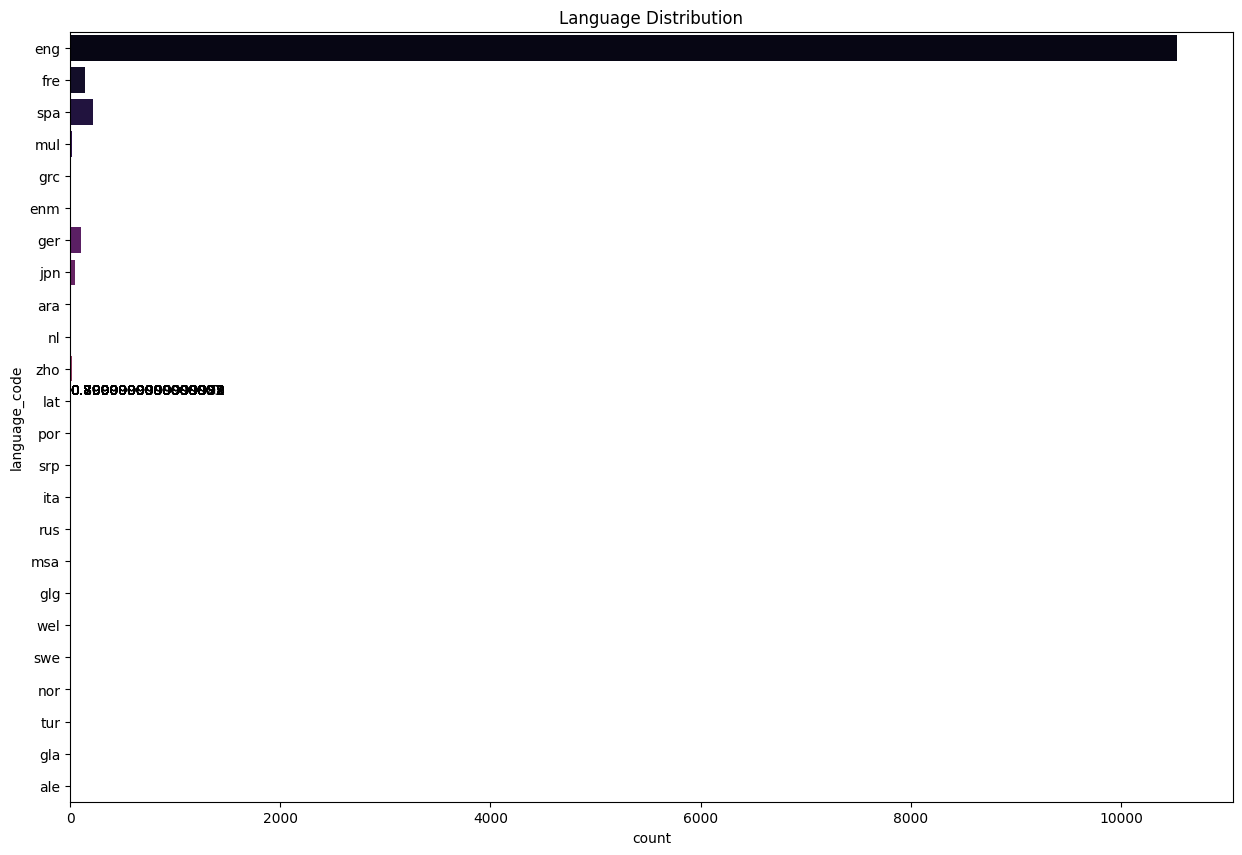

In [52]:
# Language Distribution
fig = plt.figure(figsize=(15, 10))
plt.title("Language Distribution")
ax = sns.countplot(df['language_code'], palette='inferno')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x(), p.get_height()+10))

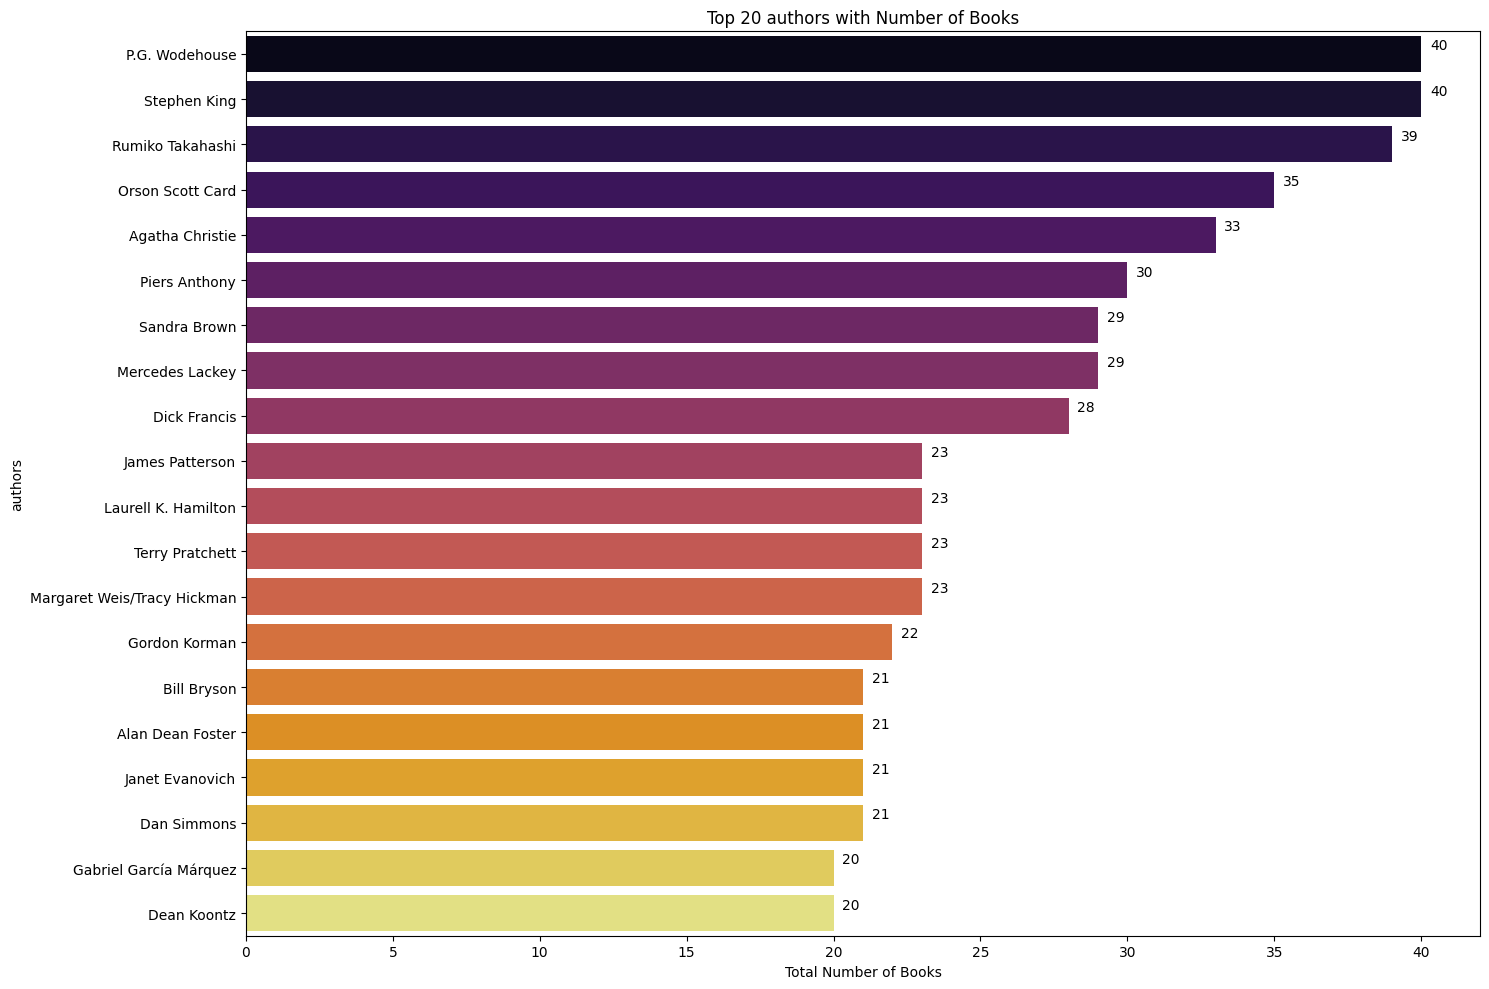

In [55]:

# Max number of books published by authors
book_count = df.groupby('authors')['title'].count().reset_index().sort_values('title', ascending=False).head(20)

plt.figure(figsize=(15,10))
# For newer versions of seaborn (0.12+)
ax = sns.barplot(x='title', y='authors', data=book_count, palette='inferno')
# Alternative syntax for older versions would be:
# ax = sns.barplot(x=book_count['title'], y=book_count['authors'], palette='inferno')

ax.set_title("Top 20 authors with Number of Books")
ax.set_xlabel("Total Number of Books")

# Add text labels for each bar
for i in ax.patches:
    ax.text(i.get_width()+0.3, i.get_y()+0.3, str(round(i.get_width())), fontsize=10, color='k')

plt.tight_layout()
plt.show()

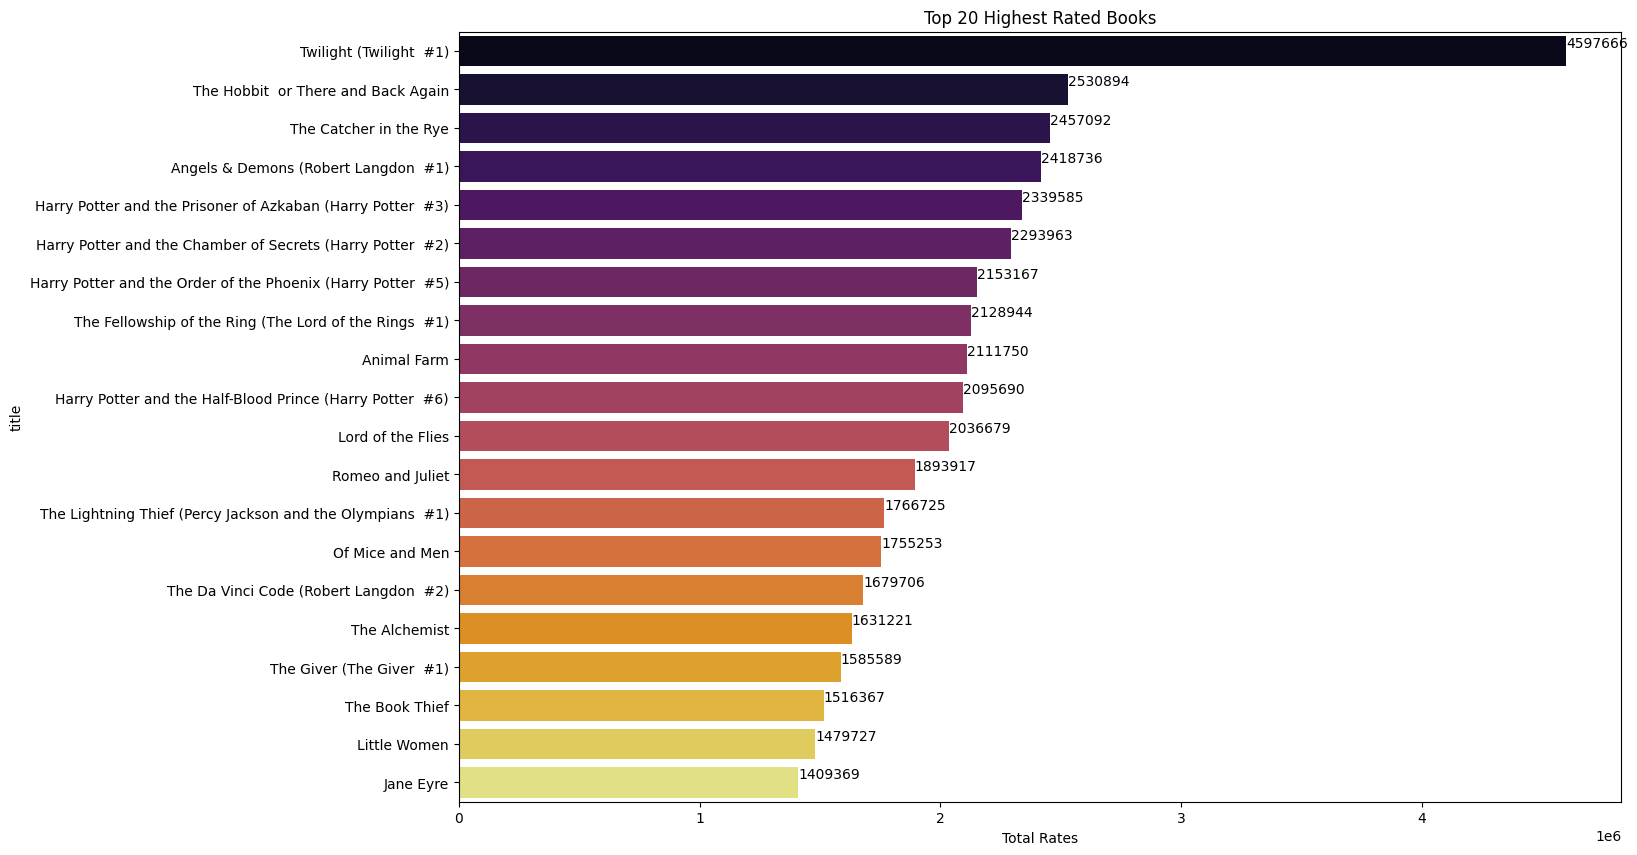

In [57]:
#Top 20 Highest Rated Books
most_rated_books = df.sort_values('ratings_count', ascending = False).head(20).set_index('title')
plt.figure(figsize=(15,10))

# For newer versions of seaborn (0.12+)
ax = sns.barplot(x='ratings_count', y='title', data=most_rated_books, palette='inferno')

ax.set_title("Top 20 Highest Rated Books")
ax.set_xlabel("Total Rates")
for i in ax.patches:
    ax.text(i.get_width()+.3, i.get_y()+0.3, str(round(i.get_width())), fontsize = 10, color = 'k')


Text(0.5, 0, 'Average rating')

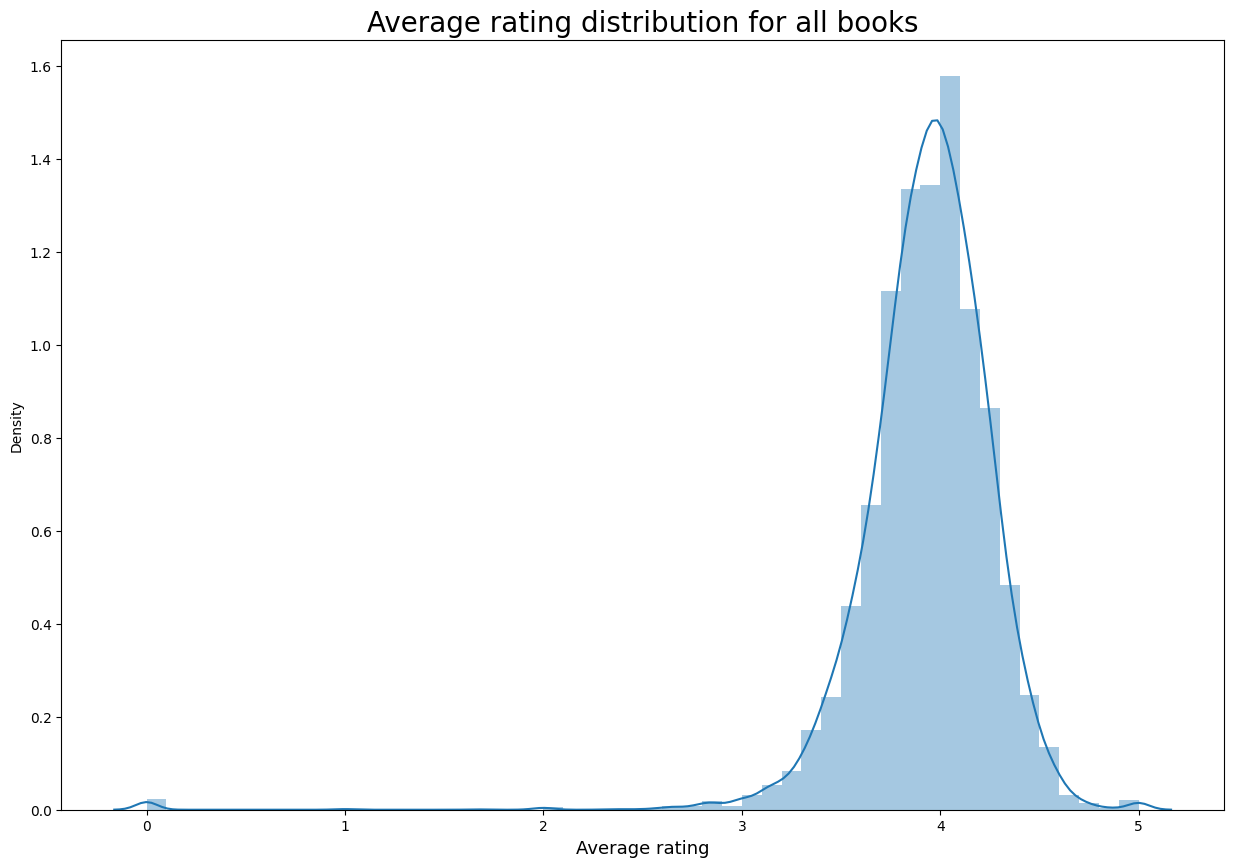

In [58]:
df.average_rating = df.average_rating.astype(float)
fig, ax = plt.subplots(figsize=[15,10])
sns.distplot(df['average_rating'],ax=ax)
ax.set_title('Average rating distribution for all books',fontsize=20)
ax.set_xlabel('Average rating',fontsize=13)


In [59]:
#Gathering the data for the year column for the books from their ISBN 13 values
def bookdata(df):
    year=[]
    pbar = ProgressBar()
    for isbn in pbar(df.isbn13):
        try:
            details = isbnlib.meta(isbn)
            year.append(details['Year'])
        except :
            #Trying out with goodreads api now
                try:
                    y = html(isbn)
                    year_extracted = reg(y) #Extracting year with regex
                    year.append(y)
                except:
                    year.append('0')                
    return year
# The finction for getting the final dataframe for the charts
def final_df(df1, l):
    year_df = pd.DataFrame(l, columns=['Year'])
    df1 = df1.reset_index(drop=True)
    final = df1[['authors', 'average_rating', 'title']].join(year_df)
    return final


In [60]:
authors = ['Gabriel García Márquez', 'Jack London', 'George Orwell', 'Jules Verne', 'Richard P. Feynman']


In [61]:
author_df0 = df[df['authors']==authors[0]]
author_df0 = author_df0[author_df0['language_code']=='eng']
author_df0

,title,authors,average_rating,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
bookID,,,,,,,,,,
7600,One Hundred Years Of Solitude,Gabriel García Márquez,4.07,9781857152234,eng,416,376,53,9/21/1995,Everyman
22175,Strange Pilgrims,Gabriel García Márquez,4.03,9781400034697,eng,208,6952,422,11/14/2006,Vintage
23876,Of Love and Other Demons,Gabriel García Márquez,3.98,9780517405093,eng,160,35045,1116,05/02/1995,Penguin Group (USA)


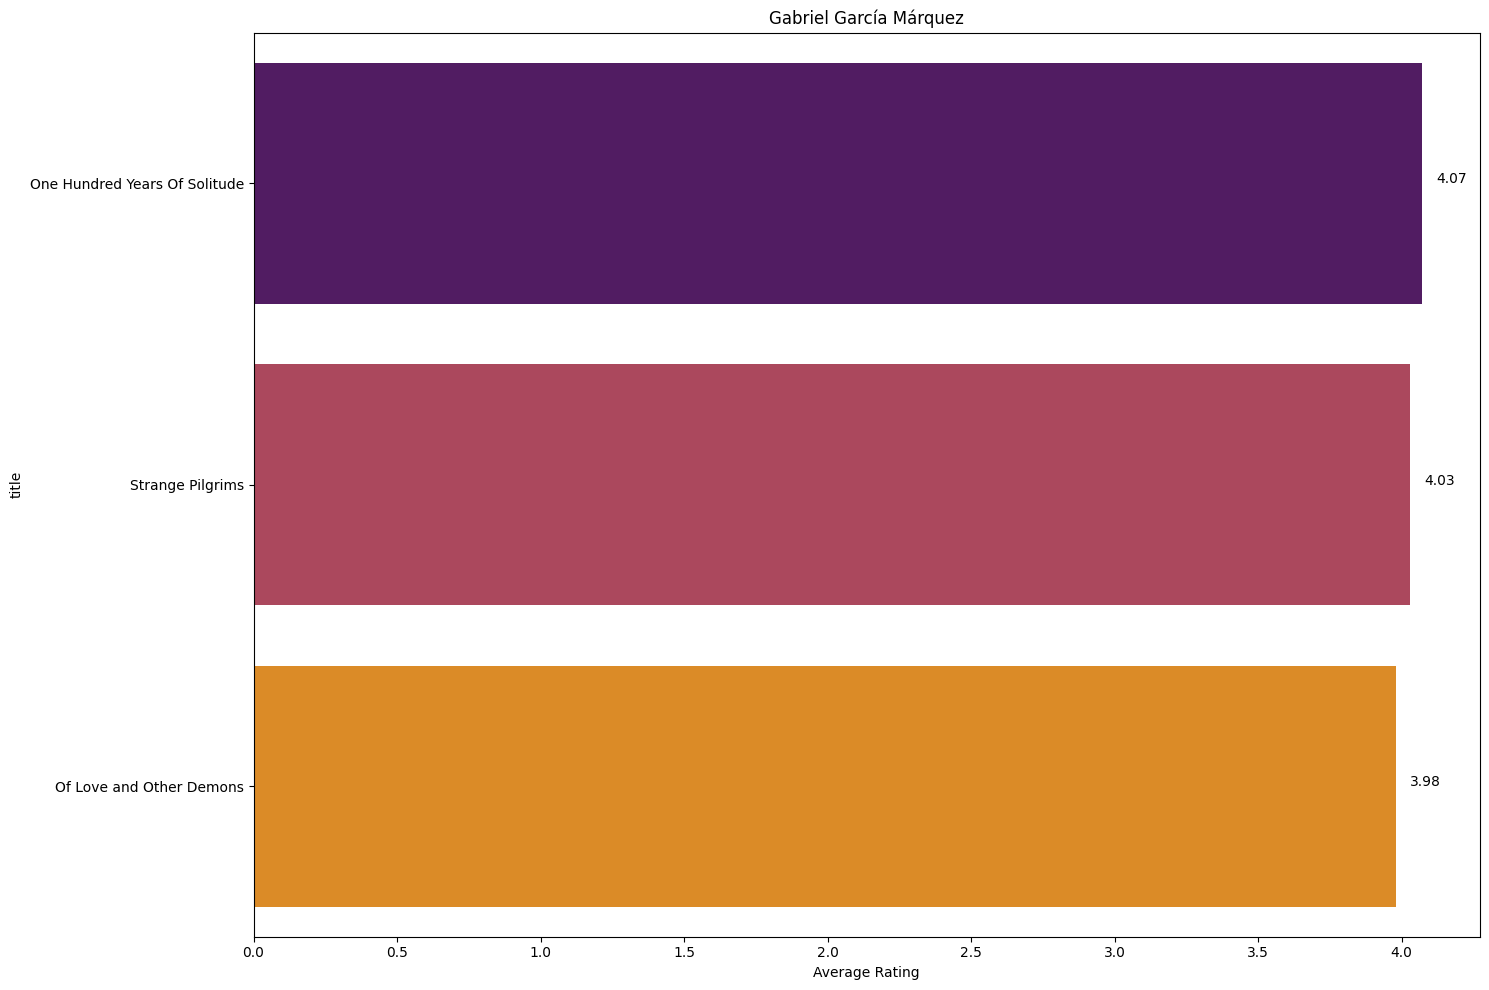

In [63]:
#Books Ratings of Gabriel García Márquez
author0 = author_df0.sort_values('average_rating', ascending=False).head(20)

plt.figure(figsize=(15,10))
# Using the newer Seaborn syntax (0.12+)
ax = sns.barplot(x='average_rating', y='title', data=author0, palette='inferno')
# Alternative for older Seaborn versions:
# ax = sns.barplot(x=author0['average_rating'], y=author0.index, palette='inferno')

ax.set_title("Gabriel García Márquez")
ax.set_xlabel("Average Rating")

# Adjust the text formatting to handle decimal values better
for i in ax.patches:
    # Format with 2 decimal places
    ax.text(i.get_width()+0.05, i.get_y()+0.4, f"{i.get_width():.2f}", fontsize=10, color='k')

plt.tight_layout()
plt.show()


In [64]:
author_df1 = df[df['authors']==authors[1]]
author_df1



,title,authors,average_rating,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
bookID,,,,,,,,,,
43035,White Fang,Jack London,3.98,9780439236195,eng,252,119589,3124,01/01/2001,Scholastic Paperbacks
43037,The Call of the Wild White Fang and Other Sto...,Jack London,3.99,9780192835147,eng,400,18720,192,8/20/1998,Oxford University Press USA
43046,Jack London Illustrated: The Call of the Wild/...,Jack London,4.26,9780517309803,eng,761,20,1,10/02/1993,Random House Value Publishing
43049,The Sea Wolf,Jack London,4.04,9781598184310,eng,425,19091,851,06/01/2005,Alan Rodgers Books


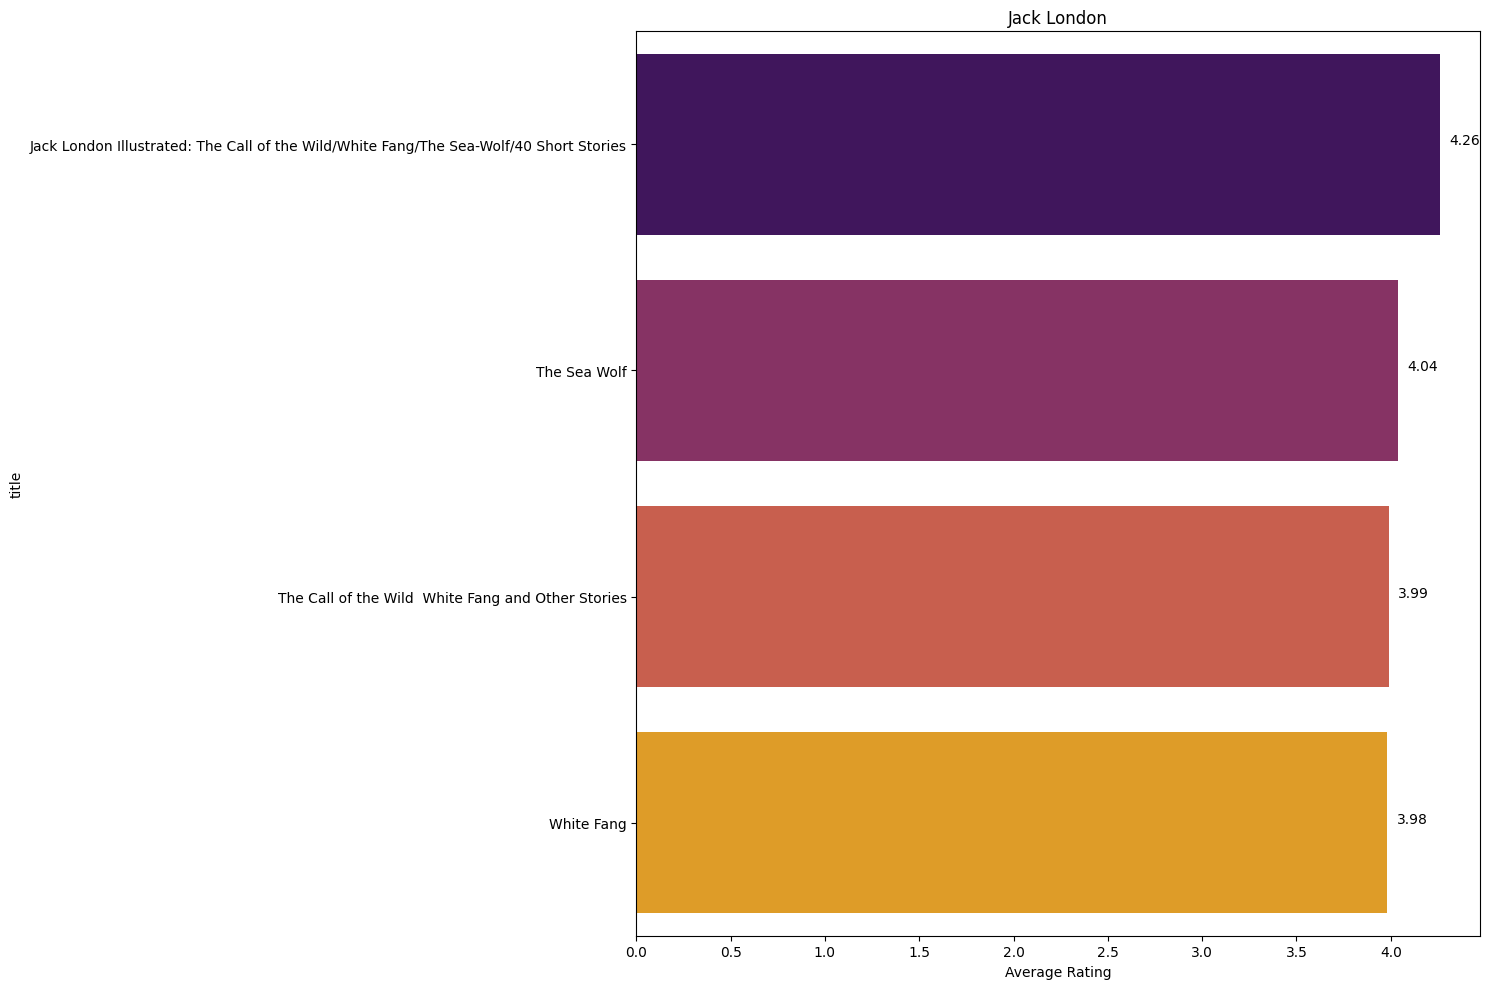

In [66]:
#Books Ratings of Jack London
author1 = author_df1.sort_values('average_rating', ascending=False).head(20)

plt.figure(figsize=(15,10))
# Using newer Seaborn syntax (0.12+)
ax = sns.barplot(x='average_rating', y='title', data=author1, palette='inferno')
# Alternative for older Seaborn versions:
# ax = sns.barplot(x=author1['average_rating'], y=author1.index, palette='inferno')

ax.set_title("Jack London")
ax.set_xlabel("Average Rating")

# Format ratings with 2 decimal places for better readability
for i in ax.patches:
    ax.text(i.get_width()+0.05, i.get_y()+0.4, f"{i.get_width():.2f}", fontsize=10, color='k')

plt.tight_layout()
plt.show()

In [67]:
author_df2 = df[df['authors']==authors[2]]
author_df2


,title,authors,average_rating,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
bookID,,,,,,,,,,
5478,Nineteen Eighty-Four,George Orwell,4.18,9781421808321,eng,387,215,17,07/01/2005,1st World Library
9644,Why I Write,George Orwell,4.03,9780143036357,eng,120,6389,541,09/06/2005,Penguin Books
9648,Keep the Aspidistra Flying,George Orwell,3.88,9780141183725,eng,277,11970,688,10/26/2000,Penguin Books Ltd
30557,Shooting an Elephant,George Orwell,4.12,9780141187396,eng,368,7029,255,06/05/2003,Penguin


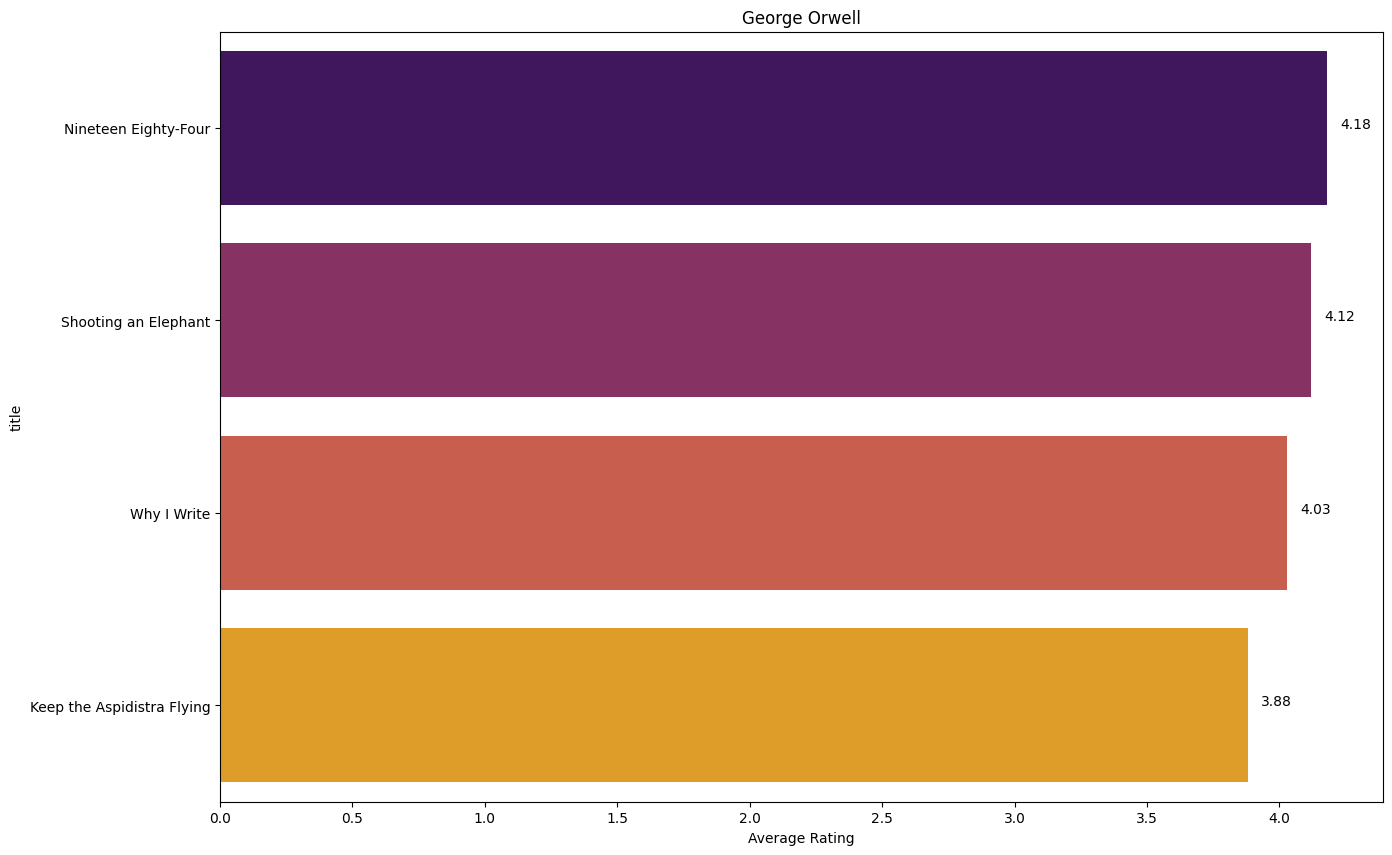

In [68]:
#Books Ratings of George Orwell
author1 = author_df2.sort_values('average_rating', ascending = False).head(20).set_index('title')
plt.figure(figsize=(15,10))
ax = sns.barplot(x=author1['average_rating'], y=author1.index, palette='inferno')

ax.set_title("George Orwell")
ax.set_xlabel("Average Rating")
for i in ax.patches:
    ax.text(i.get_width()+.05, i.get_y()+.4, str(i.get_width()), fontsize = 10, color = 'k')


In [69]:
author_df3 = df[df['authors']==authors[3]]
author_df3

,title,authors,average_rating,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
bookID,,,,,,,,,,
32827,From the Earth to the Moon (Extraordinary Voya...,Jules Verne,3.78,9781598184549,eng,136,17325,421,10/01/2006,Aegypan
32829,Journey to the Center of the Earth (Extraordin...,Jules Verne,3.86,9780553213973,eng,240,107189,2510,4/25/2006,Bantam
32832,The Lighthouse at the End of the World,Jules Verne,3.64,9781589630949,eng,260,1752,40,3/20/2001,Fredonia Books (NL)
32849,Adrift in the Pacific: Two Years Holiday (Extr...,Jules Verne,3.99,9781410102157,eng,300,1956,39,4/24/2003,Fredonia Books (NL)


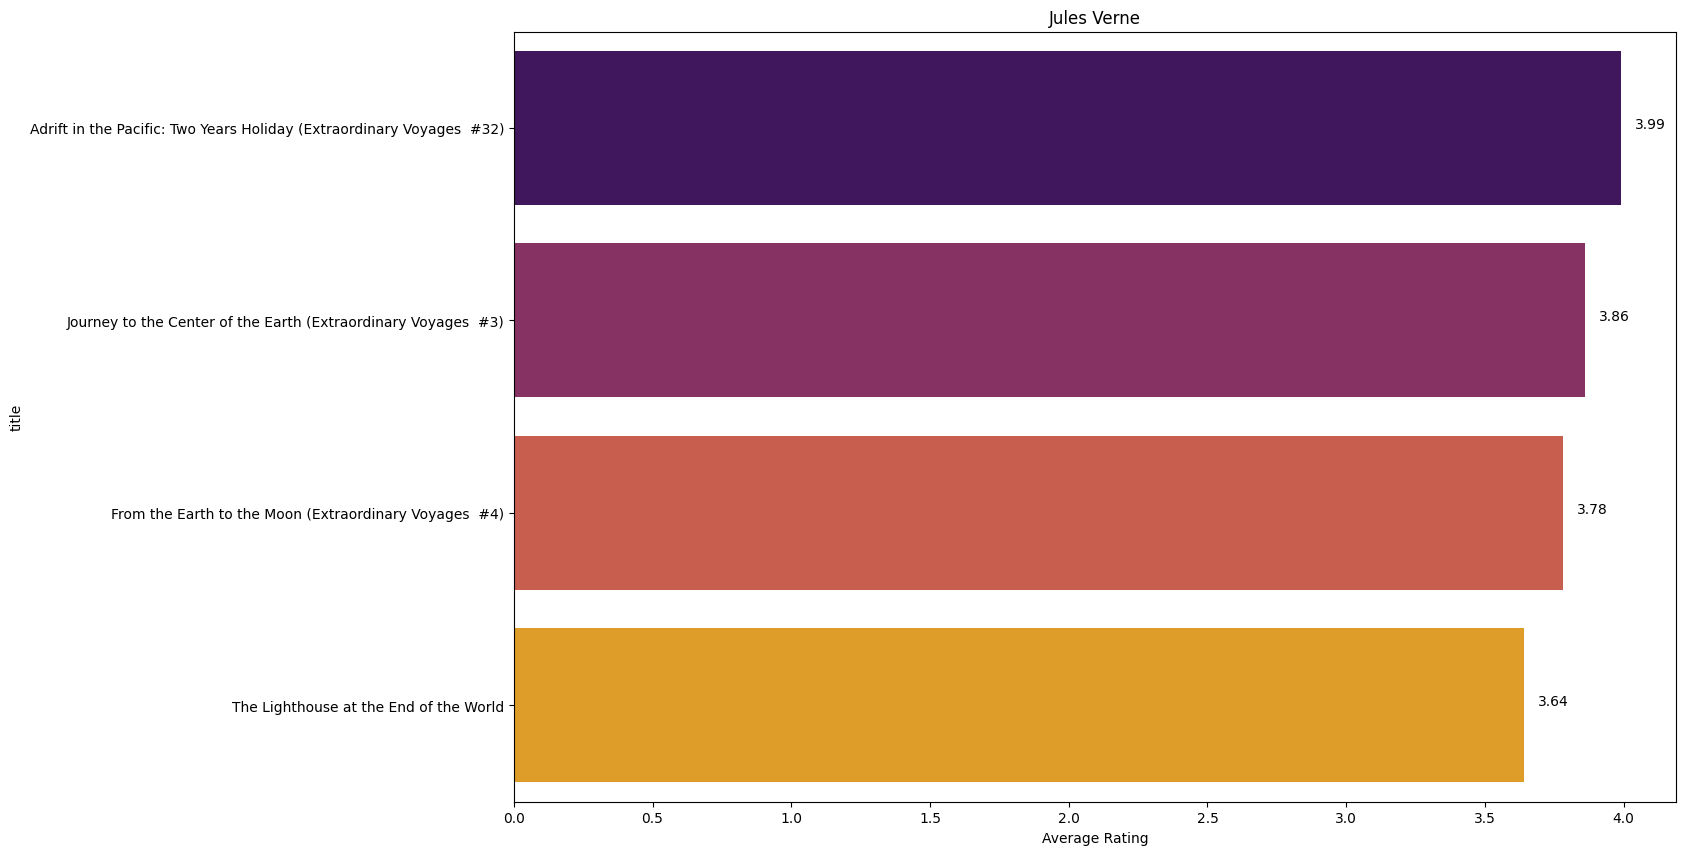

In [70]:
#Books Ratings of Jules Verne
author3 = author_df3.sort_values('average_rating', ascending = False).head(20).set_index('title')
plt.figure(figsize=(15,10))
ax = sns.barplot(x=author3['average_rating'], y=author3.index, palette='inferno')
ax.set_title("Jules Verne")
ax.set_xlabel("Average Rating")
for i in ax.patches:
    ax.text(i.get_width()+.05, i.get_y()+.4, str(i.get_width()), fontsize = 10, color = 'k')



In [71]:
author_df4 = df[df['authors']==authors[4]]
author_df4

,title,authors,average_rating,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
bookID,,,,,,,,,,
5544,Surely You're Joking Mr. Feynman!: Adventures...,Richard P. Feynman,4.28,9780393316049,eng,391,106526,3685,04/12/1997,W. W. Norton & Company
5548,What Do You Care What Other People Think?,Richard P. Feynman,4.27,9780393320923,eng,256,15700,556,01/11/2001,W.W. Norton & Company
5552,QED: The Strange Theory of Light and Matter,Richard P. Feynman,4.24,9780691024172,eng,158,13463,320,10/21/1988,Princeton University Press
17275,The Very Best of the Feynman Lectures,Richard P. Feynman,4.18,9780465099009,eng,180,123,21,10/04/2005,Basic Books
17276,The Feynman Lectures on Physics Vols 3-4,Richard P. Feynman,4.71,9780738209258,eng,0,21,0,05/12/2004,Basic Books
17277,The Feynman Lectures on Physics Vols 7-8,Richard P. Feynman,4.80,9780738209272,eng,0,20,0,01/03/2006,Basic Books
17279,The Feynman Lectures on Physics Vols 5-6,Richard P. Feynman,4.59,9780738202839,eng,12,22,0,11/03/2004,Basic Books
17364,Surely You're Joking Mr. Feynman!,Richard P. Feynman,4.28,9780099173311,eng,350,1837,178,12/17/2006,Vintage
17375,The Meaning of It All: Thoughts of a Citizen-S...,Richard P. Feynman,4.05,9780465023943,eng,144,5907,290,04/06/2005,Basic Books


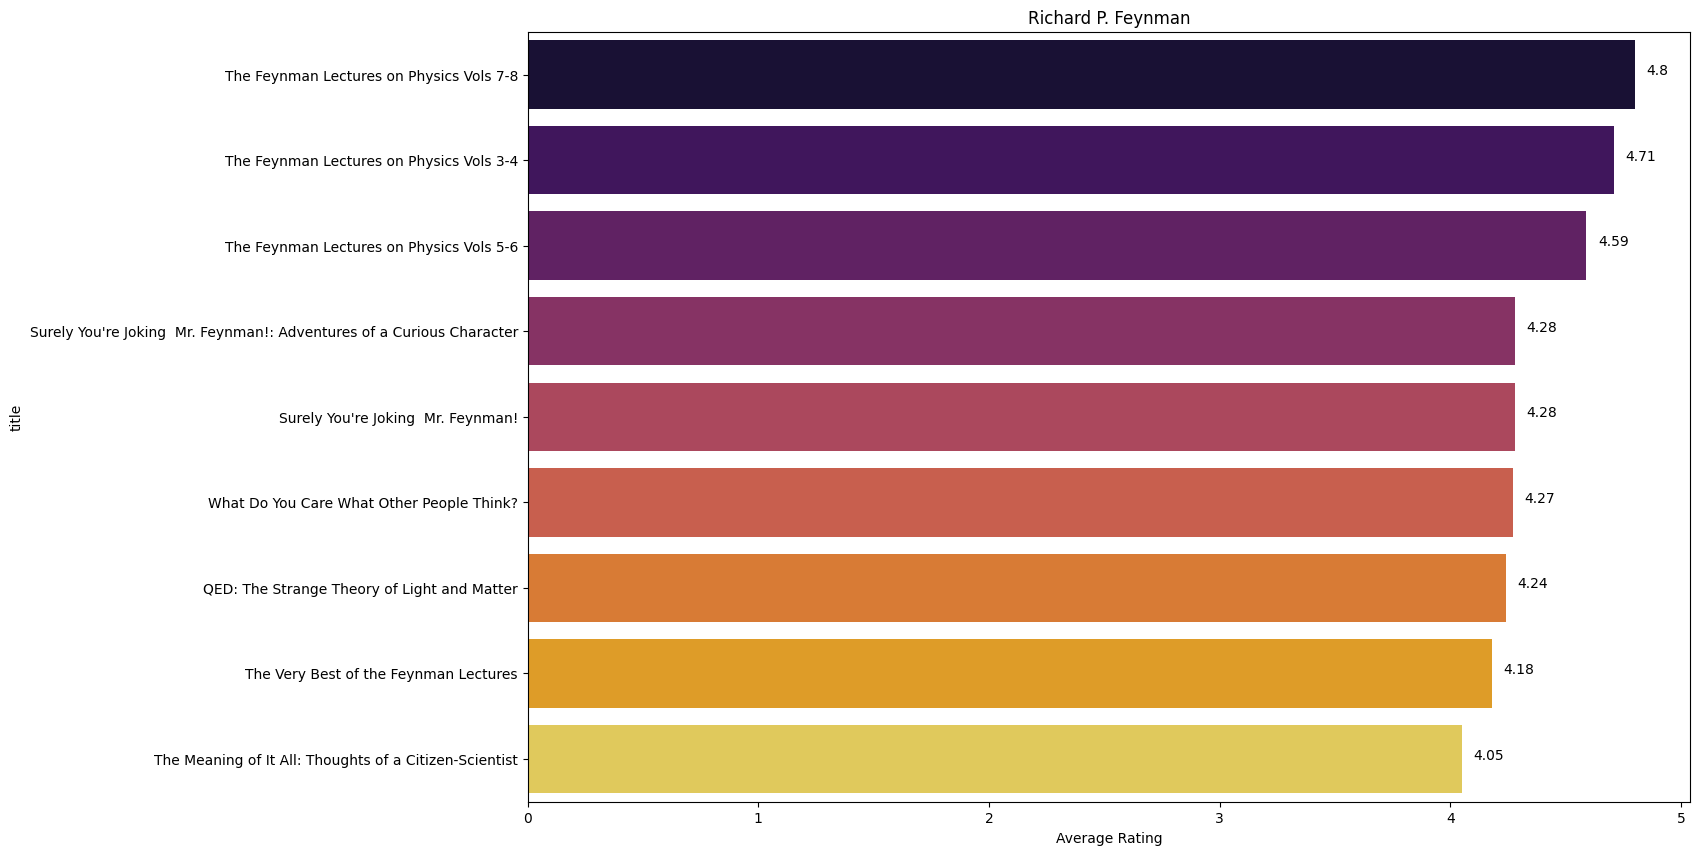

In [72]:
#Books Ratings of Richard P. Feynman
author4 = author_df4.sort_values('average_rating', ascending = False).head(20).set_index('title')
plt.figure(figsize=(15,10))
ax = sns.barplot(x=author4['average_rating'], y=author4.index, palette='inferno')
ax.set_title("Richard P. Feynman")
ax.set_xlabel("Average Rating")
for i in ax.patches:
    ax.text(i.get_width()+.05, i.get_y()+.4, str(i.get_width()), fontsize = 10, color = 'k')

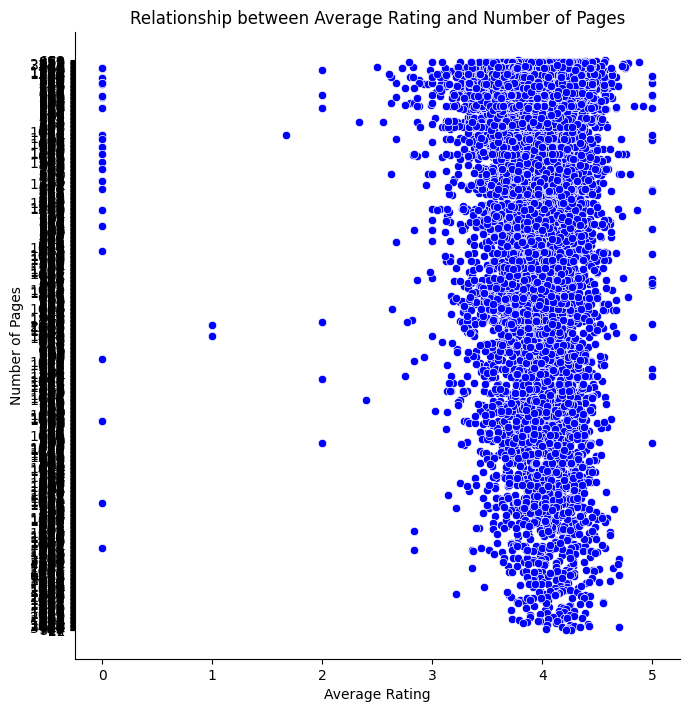

In [84]:
#Relationship between Average Rating and Number of Pages
ax = sns.relplot(x="average_rating", y="  num_pages", data = df, color = 'blue',sizes=(200, 200), height=7, marker='o')
plt.title("Relationship between Average Rating and Number of Pages",fontsize = 12)
ax.set_axis_labels("Average Rating", "Number of Pages")


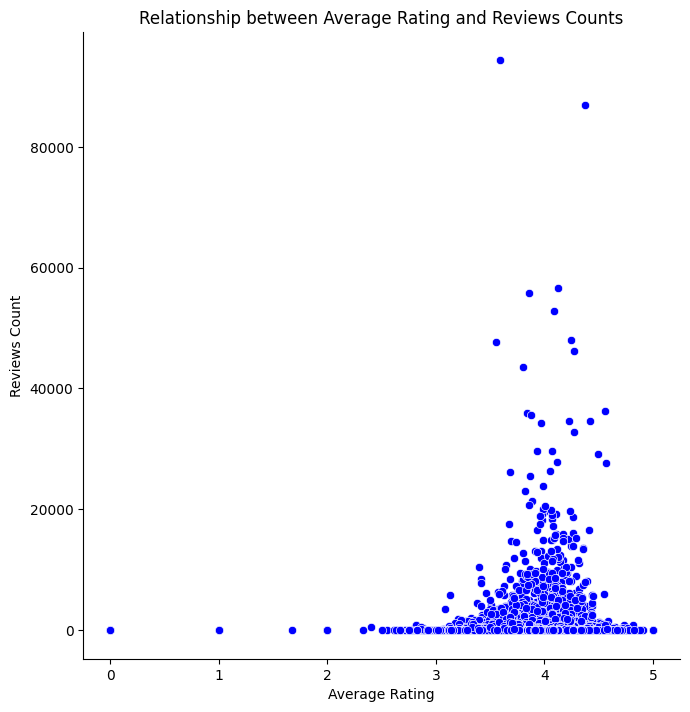

In [85]:
#Relationship between Average Rating and Reviews Counts
ax = sns.relplot(x="average_rating", y="text_reviews_count", data = df, color = 'blue',sizes=(100, 200), height=7, marker='o')
plt.title("Relationship between Average Rating and Reviews Counts",fontsize = 12)
ax.set_axis_labels("Average Rating", "Reviews Count")

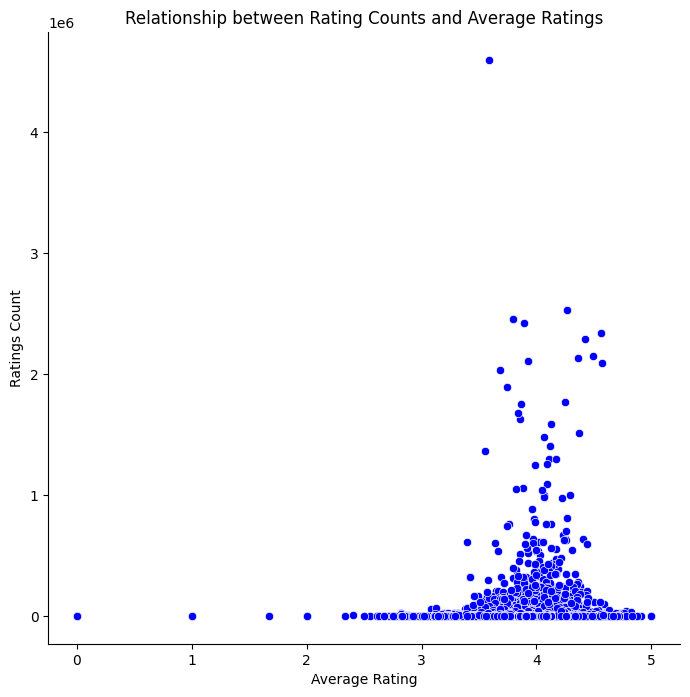

In [86]:
#Relationship between Average Rating and Ratting Counts
ax = sns.relplot(x="average_rating", y="ratings_count", data = df, color = 'blue',sizes=(100, 200), height=7, marker='o')
plt.title("Relationship between Rating Counts and Average Ratings",fontsize = 12)
ax.set_axis_labels("Average Rating", "Ratings Count")



In [87]:
trial = df[['average_rating', 'ratings_count']]
data = np.asarray([np.asarray(trial['average_rating']), np.asarray(trial['ratings_count'])]).T


Text(0.5, 1.0, 'Elbow Curve')

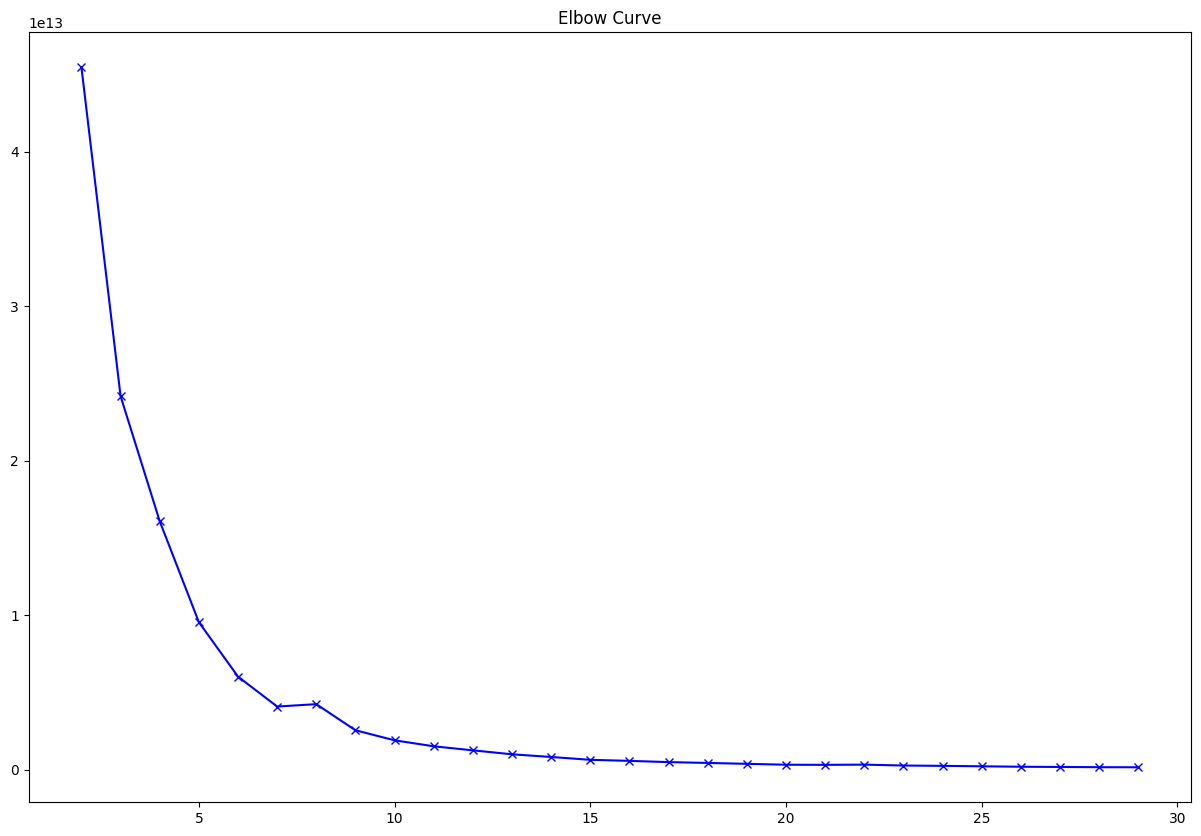

In [88]:
X = data
distortions = []
for k in range(2,30):
    k_means = KMeans(n_clusters = k)
    k_means.fit(X)
    distortions.append(k_means.inertia_)

fig = plt.figure(figsize=(15,10))
plt.plot(range(2,30), distortions, 'bx-')
plt.title("Elbow Curve")

In [89]:
#Computing K means with K = 5, thus, taking it as 5 clusters
centroids, _ = kmeans(data, 5)

#assigning each sample to a cluster
#Vector Quantisation:

idx, _ = vq(data, centroids)

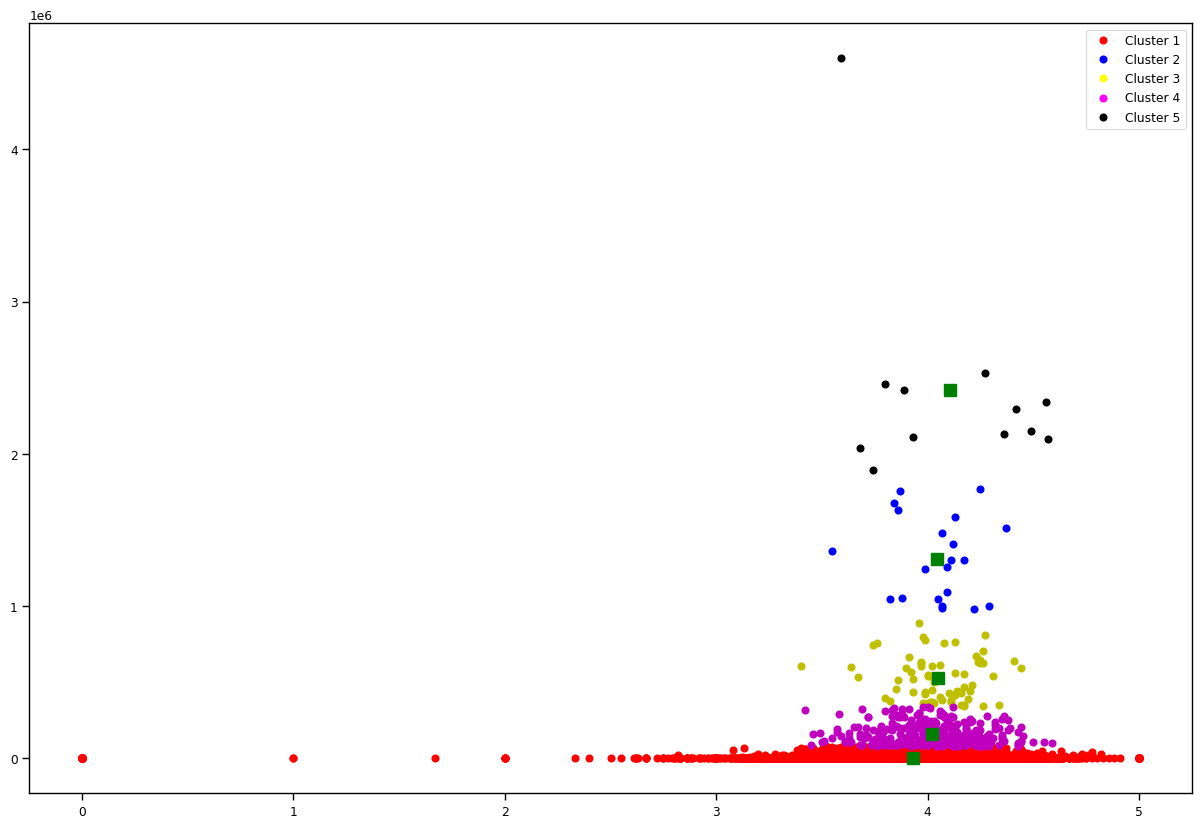

In [90]:
# some plotting using numpy's logical indexing
sns.set_context('paper')
plt.figure(figsize=(15,10))
plt.plot(data[idx==0,0],data[idx==0,1],'or',#red circles
     data[idx==1,0],data[idx==1,1],'ob',#blue circles
     data[idx==2,0],data[idx==2,1],'oy', #yellow circles
     data[idx==3,0],data[idx==3,1],'om', #magenta circles
     data[idx==4,0],data[idx==4,1],'ok',#black circles
)
plt.plot(centroids[:,0],centroids[:,1],'sg',markersize=8, )


circle1 = Line2D(range(1), range(1), color = 'red', linewidth = 0, marker= 'o', markerfacecolor='red')
circle2 = Line2D(range(1), range(1), color = 'blue', linewidth = 0,marker= 'o', markerfacecolor='blue')
circle3 = Line2D(range(1), range(1), color = 'yellow',linewidth=0,  marker= 'o', markerfacecolor='yellow')
circle4 = Line2D(range(1), range(1), color = 'magenta', linewidth=0,marker= 'o', markerfacecolor='magenta')
circle5 = Line2D(range(1), range(1), color = 'black', linewidth = 0,marker= 'o', markerfacecolor='black')

plt.legend((circle1, circle2, circle3, circle4, circle5)
           , ('Cluster 1','Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5'), numpoints = 1, loc = 0, )
plt.show()

In [91]:
def segregation(data):
    values = []
    for val in data.average_rating:
        if val>=0 and val<=1:
            values.append("Between 0 and 1")
        elif val>1 and val<=2:
            values.append("Between 1 and 2")
        elif val>2 and val<=3:
            values.append("Between 2 and 3")
        elif val>3 and val<=4:
            values.append("Between 3 and 4")
        elif val>4 and val<=5:
            values.append("Between 4 and 5")
        else:
            values.append("NaN")
    print(len(values))
    return values


In [92]:
df['Ratings_Dist'] = segregation(df)


11123


In [93]:
books_features = pd.concat([df['Ratings_Dist'].str.get_dummies(sep=","), df['average_rating'], df['ratings_count']], axis=1)
books_features.head()


,Between 0 and 1,Between 1 and 2,Between 2 and 3,Between 3 and 4,Between 4 and 5,average_rating,ratings_count
bookID,,,,,,,
1,0,0,0,0,1,4.57,2095690
2,0,0,0,0,1,4.49,2153167
4,0,0,0,0,1,4.42,6333
5,0,0,0,0,1,4.56,2339585
8,0,0,0,0,1,4.78,41428


In [94]:
books_features.shape


(11123, 7)

In [ ]:
min_max_scaler = MinMaxScaler()
books_features = min_max_scaler.fit_transform(books_features)

In [97]:
np.round(books_features, 2)

array([[0.  , 0.  , 0.  , ..., 1.  , 0.91, 0.46],
       [0.  , 0.  , 0.  , ..., 1.  , 0.9 , 0.47],
       [0.  , 0.  , 0.  , ..., 1.  , 0.88, 0.  ],
       ...,
       [0.  , 0.  , 0.  , ..., 0.  , 0.79, 0.  ],
       [0.  , 0.  , 0.  , ..., 0.  , 0.74, 0.  ],
       [0.  , 0.  , 0.  , ..., 0.  , 0.78, 0.  ]], shape=(11123, 7))

In [98]:
model = neighbors.NearestNeighbors(n_neighbors=6, algorithm='ball_tree')
model.fit(books_features)
distance, indices = model.kneighbors(books_features)

In [99]:
def get_index_from_name(name):
    return df[df["title"]==name].index.tolist()[0]

all_books_names = list(df.title.values)

def get_id_from_partial_name(partial):
    for name in all_books_names:
        if partial in name:
            print(name,all_books_names.index(name))


In [100]:
def print_similar_books(query=None,id=None):
    if id:
        for id in indices[id][1:]:
            print(df.iloc[id]["title"])
    if query:
        found_id = get_index_from_name(query)
        for id in indices[found_id][1:]:
            print(df.iloc[id]["title"])


In [102]:
name = input("Enter any text: ")
print(print_similar_books(name))



A Clash of Kings (A Song of Ice and Fire  #2)
The Letters of Virginia Woolf: Volume Four  1929-1931
Poetry  Tales and Selected Essays
Collected Shorter Fiction: Volume I
The Reverse of the Medal (Aubrey & Maturin #11)
None


In [103]:
print_similar_books("Caesar (Masters of Rome  #5)")


The Metaphysical Club
One Hundred Years of Solitude
Alice's Adventures in Wonderland and Through the Looking-Glass (Alice's Adventures in Wonderland  #1-2)
In Cold Blood
Desperation / The Regulators: Box Set


In [104]:
print_similar_books("Lord of the Flies")


Introduction to the Philosophy of History with Selections from The Philosophy of Right
Marie  Dancing
The Odyssey
The Hour Before Dark
A Philosophical Enquiry into the Origin of our Ideas of the Sublime and Beautiful
